[*********************100%***********************]  1 of 1 completed


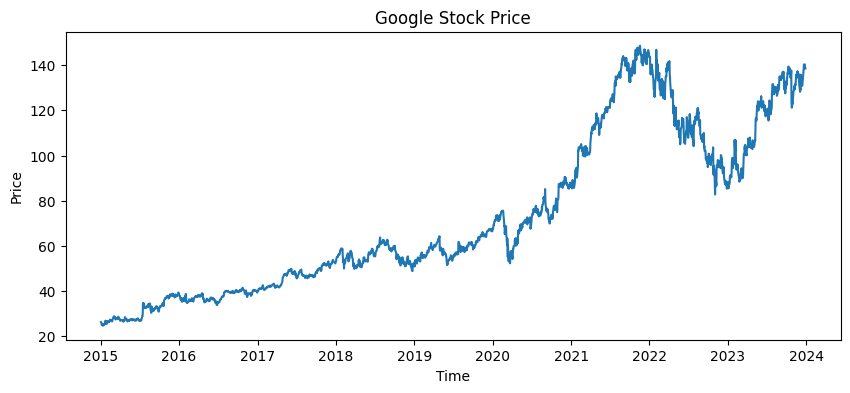

In [7]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout

# 2. LOAD DATA
data = yf.download('GOOGL', start='2015-01-01', end='2024-01-01')
df = data[['Close']]

plt.figure(figsize=(10,4))
plt.plot(df['Close'])
plt.title("Google Stock Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [8]:
# 3. NORMALIZATION
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 4. CREATE SEQUENCES
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)
time_step = 60
X, y = create_dataset(scaled_data, time_step)

# 5. TRAIN TEST SPLIT
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. BUILD MODEL
model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.2),
    SimpleRNN(50),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')


/Users/avartanathlay/my_jupyter_env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


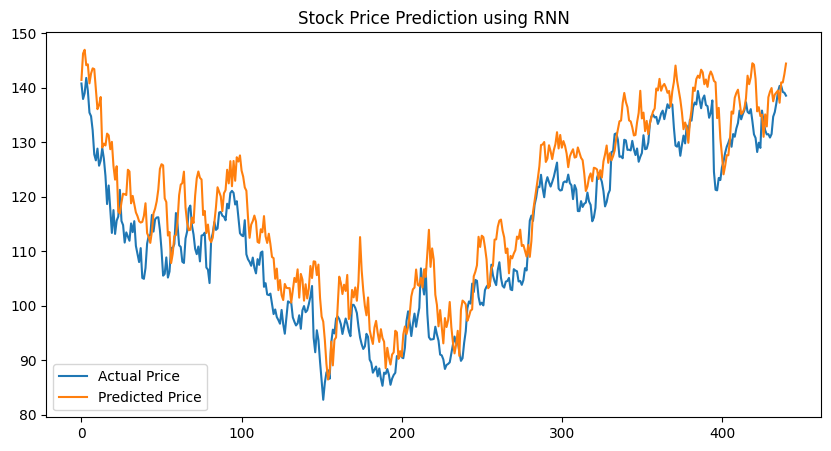

In [9]:
# 7. TRAIN MODEL
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0  
)

# 8. PREDICTIONS
test_pred = model.predict(X_test, verbose=0)
test_pred = scaler.inverse_transform(test_pred)
y_test_inv = scaler.inverse_transform(y_test)

# 9. RESULT GRAPH
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual Price')
plt.plot(test_pred, label='Predicted Price')
plt.title("Stock Price Prediction using RNN")
plt.legend()
plt.show()

In [10]:
# 10. FUTURE PREDICTION
last_data = scaled_data[-time_step:]
future_input = last_data.reshape(1, time_step, 1)
future_preds = []
for i in range(10):
    pred = model.predict(future_input, verbose=0)[0]
    future_preds.append(pred)
    future_input = np.append(future_input[:,1:,:], [[pred]], axis=1)
future_preds = scaler.inverse_transform(future_preds)

# 11. CLEAN OUTPUT
print("\nNext 10 Days Prediction:\n")
for i, price in enumerate(future_preds, 1):
    print(f"Day {i}: ${price[0]:.2f}")


Next 10 Days Prediction:

Day 1: $148.14
Day 2: $146.35
Day 3: $149.64
Day 4: $145.66
Day 5: $150.25
Day 6: $148.39
Day 7: $151.15
Day 8: $149.56
Day 9: $151.34
Day 10: $153.07
